In [1]:
#conda install -c conda forge tqdm

## LeNet

In [2]:
# 필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환 (전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim # 경사 하강법을 이용해 가중치를 구하기 위한 옵티마이저 라이브러리
 
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm # 진행 상황을 가시적으로 표현해주는데, 특히 모델의 학습 경과를 확인하고 싶을 때 사용
import random
from matplotlib import pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
# 이미지 데이터셋 전처리
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale = (0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }
    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [4]:
# 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
path = os.getcwd()
cat_directory = os.path.join(path, 'chap06/data/dogs-vs-cats/Cat/')
dog_directory = os.path.join(path, 'chap06/data/dogs-vs-cats/Dog/')

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in 
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in 
                               os.listdir(dog_directory)])

# 개와 고양이 이미지들을 합쳐서 image_filepaths에 저장
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] 
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [5]:
print(len(correct_images_filepaths))
print(len(cat_images_filepaths))
print(len(dog_images_filepaths))

502
251
251


In [6]:
# 테스트 데이터셋 이미지 확인 함수
def display_image_grid(images_filepaths, predicted_labels = (), cols = 5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows = rows, ncols = cols, figsize = (12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        # 예측과 정답 레이블이 동일하다면 초록색, 그렇지 않다면 빨간색으로 표시
        color = "green" if true_label == predicted_label else "red"
        ax.ravel()[i].imshow(image) # 개별 이미지 출력
        ax.ravel()[i].set_title(predicted_label, color = color) # predicted label을 타이틀로 사용
        ax.ravel()[i].set_axis_off() # 이미지 축 제거
    plt.tight_layout() # 이미지 여백 조정
    plt.show()

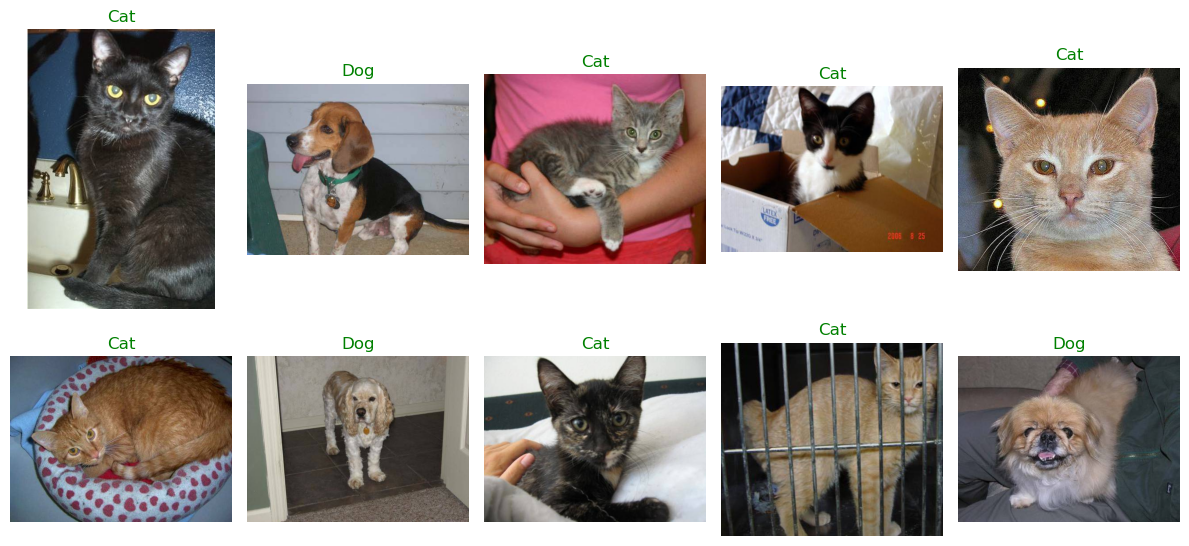

In [7]:
# 테스트 데이터셋 이미지 출력
display_image_grid(test_images_filepaths)

- 다수의 개와 고양이 이미지가 포함된 데이터에서 이들을 예측하는 것이 목표
- 레이블 이미지에서 고양이와 개가 포함될 확률을 코드로 구현

In [8]:
# 이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform = None, phase = 'train'):
        self.file_list = file_list
        # DogvsCatDatset 클래스를 호출할 때 transform에 대한 매개 변수를 받아옴
        self.transform = transform 
        self.phase = phase #'train' 적용
    
    # images_filepaths 데이터셋의 전체 길이 반환
    def __len__(self):
        return len(self.file_list)
    
    # 데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태가 됨
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져옴
        img_transformed = self.transform(img, self.phase) # 이미지에 'train' 전처리 적용
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [9]:
# 변수값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [10]:
# 이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, 
                                transform=ImageTransform(size, mean, std), phase = 'train')
val_dataset = DogvsCatDataset(val_images_filepaths, 
                              transform=ImageTransform(size, mean, std), phase = 'val')
index = 0
# 훈련 데이터 (train_dataset.__getitem__[0][0]의 크기 size() 출력)
print(train_dataset.__getitem__(index)[0].size())
# 훈련 데이터의 레이블 출력
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


- 이미지는 컬러 상태에서 224 * 224 크기를 가지며 레이블이 0으로 출력됨.

- 즉, 훈련 데이터셋의 레이블이 0을 갖기 때문에 '고양이' 이미지가 포함되어있다는 것을 유추할 수 있음

In [11]:
# 데이터로더 정의
train_dataloader = DataLoader(train_dataset, batch_size= batch_size, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size= batch_size, shuffle = False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 1, 0, 1, 1, 1])


In [12]:
# 모델의 네트워크 클래스
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 2D 합성곱층 적용 
        # 입력: (3, 224, 224)
        # 출력: (16, 220, 220) (weight-kernel_size + 1)/stride; 224-5+1 = 220
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, 
                              stride = 1, padding = 0)
        # 음수는 0으로 만들고 나머지는 그대로 통과 
        # (16, 220, 220)
        self.relu1 = nn.ReLU()
        # 최대 풀링층 (2 * 2 영역에서 최댓값 하나만 선택) -> (16, 110, 110)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        # 입력: (16, 110, 110)
        # 출력: (32, 106, 106); 110 - 5 + 1
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5,
                              stride = 1, padding = 0)
        # (32, 106, 106)
        self.relu2 = nn.ReLU()
        # 최대 풀링층 (2 * 2 영역에서 최댓값 하나만 선택) -> (32, 53, 53)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # 완전 연결층, 일렬로 펼쳐서 완전 연결층으로 넣음
        # 전체 입력 뉴런 수: 32 * 53 * 53
        # 출력: 512
        self.fc1 = nn.Linear(32*53*53, 512)
        self.relu5 = nn.ReLU()
        # 입력 : 512
        # 출력: 2개의 노드
        self.fc2 = nn.Linear(512, 2)
        # dim = 1; 각 샘플의 열 방향으로 softmax 적용
        self.output = nn.Softmax(dim = 1)

    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = out.view(out.size(0), -1) # 완전 연결층에 데이터를 전달하기 위해 데이터 형태를 1차원으로 변경
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out


In [13]:
# 모델 객체 생성
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [14]:
#pip install torchsummary

In [15]:
from torchsummary import summary
summary(model, input_size = (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [16]:
# 학습 가능한 파라미터 수 확인
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model):,} trainable_parameters')

The model has 46,038,242 trainable_parameters


In [17]:
# 옵티마이저와 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr = 0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [18]:
model = model.to(device)
criterion = criterion.to(device)

In [19]:
# 모델의 학습 함수 정의
import time
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch): # epoch를 10으로 설정했으므로 10회 반복
        print(f'Epoch {epoch + 1}/{num_epoch}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() # 모델을 학습시키겠다는 의미
            else:
                model.eval()
            epoch_loss = 0.0
            epoch_corrects = 0
            # 이때 dataloader_dict는 훈련 데이터셋
            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device) # 훈련 데이터셋 CPU에 할당
                labels = labels.to(device)
                optimizer.zero_grad() # 역전파 단계 실행 전 기울기를 0으로 초기화

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # 손실 함수를 이용한 오차 계산

                    if phase == 'train':
                        loss.backward() # 모델의 학습 가능한 모든 파라미터에 대해 기울기 계산
                        optimizer.step() # optimizer의 step 함수를 호출하면 파라미터를 갱신
                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data) # 정답과 예측이 일치하면, 일치한 개수의 합을 epoch_corrects에 저장
            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산(오차를 데이터셋 길이로 나누어 계산)
            epoch_acc = epoch_corrects.float() / len(dataloader_dict[phase].dataset) # 최종 정확도 계산 (epoch_corrects를 데이터셋 길이로 나누어서 계산)

            print(f'{phase}: Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc: # 검증 데이터셋에 대한 가장 최적의 정확도 저장
                best_acc = epoch_acc
                best_models_wts = model.state_dict()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60 :.0f}m {time_elapsed % 60:.0f}')
    print(f'Best val Acc: {best_acc:.4f}')
    return model
    

In [20]:
import time
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/var/folders/39/w11v66x90d9bmgkv6q0r4cc80000gn/T/ipykernel_9210/2776491944.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train: Loss: 0.6936 Acc: 0.4975


  0%|          | 0/3 [00:00<?, ?it/s]

...

val: Loss: 0.6891 Acc: 0.5435
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train: Loss: 0.6612 Acc: 0.6000


  0%|          | 0/3 [00:00<?, ?it/s]

val: Loss: 0.6817 Acc: 0.5652
Training complete in 0m 45
Best val Acc: 0.5761


In [21]:
# 모델 테스트를 위한 함수 정의
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad(): 
    # 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음을 나타냄 (훈련 데이터셋 모델 학습과의 차이점)
    for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase = 'val') # 테스트 데이터셋 전처리 적용
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim = 1)[:,1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])
    res = pd.DataFrame({
            'id': id_list,
            'label': pred_list
        })
    
    res.sort_values(by = 'id', inplace=True)
    res.reset_index(drop=True, inplace=True)

    res.to_csv('chap06/data/LeNet', index = False) # 데이터 프레임을 csv 파일로 저장


/var/folders/39/w11v66x90d9bmgkv6q0r4cc80000gn/T/ipykernel_9210/4032984098.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
# 테스트 데이터셋의 예측 결과 호출
res.head(10)

,id,label
0,109,0.473787
1,145,0.417280
2,15,0.504538
3,162,0.512119
4,167,0.489410
5,200,0.430772
6,210,0.575163
7,211,0.607660
8,213,0.389038
9,224,0.573102


In [23]:
# 테스트 데이터셋 이미지를 출력하기 위한 함수 정의
class_ = classes = {0: 'cat', 1: 'dog'} # cat, dog에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols = 5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows = rows, ncols = cols, figsize = (12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        a = random.choice(res['id'].values) # 데이터 프레임의 id라는 칼럼에서 임의로 데이터를 가져옴
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5: # 레이블 값이 0.5보다 크면 개
            label = 1
        else: # 레이블 값이 0.5보다 작다면 고양이
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

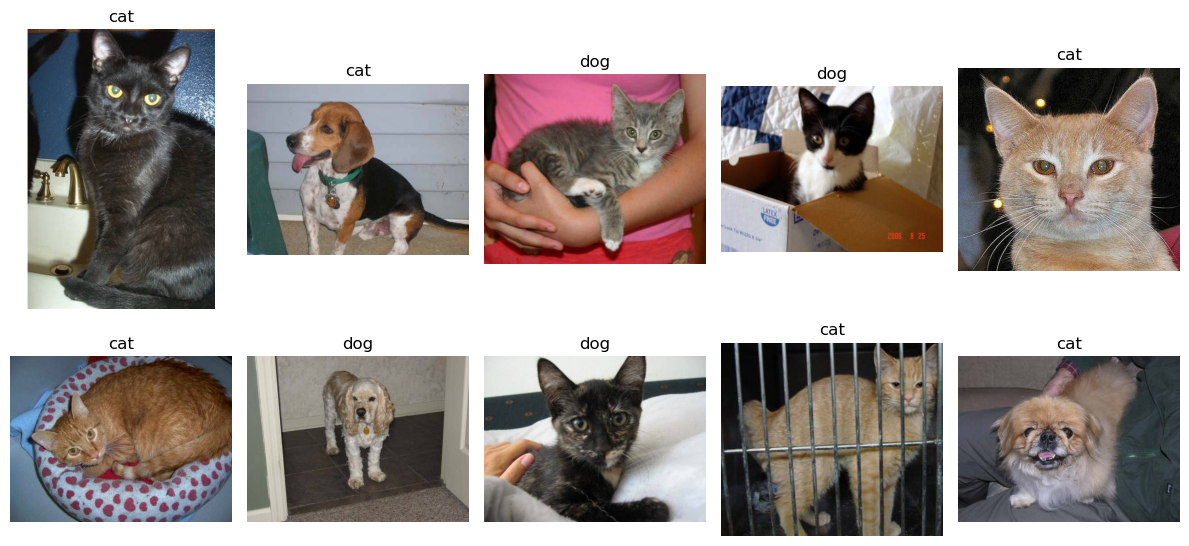

In [24]:
# 테스트 데이터셋 예측 결과 이미지 출력
display_image_grid(test_images_filepaths)

## AlexNet

In [83]:
# 필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환 (전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim # 경사 하강법을 이용해 가중치를 구하기 위한 옵티마이저 라이브러리
 
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm # 진행 상황을 가시적으로 표현해주는데, 특히 모델의 학습 경과를 확인하고 싶을 때 사용

device = torch.device("cpu")

- device를 "mps"로 설정하면 AdaptiveAvgPool2d에서 input/output 크기가 안 맞아서 MPS에서는 에러 발생
- CPU를 사용

In [84]:
# 이미지 데이터셋 전처리
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale = (0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }
    def __call__(self, img, phase):
        return self.data_transform[phase](img)
    
# 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
path = os.getcwd()
cat_directory = os.path.join(path, 'chap06/data/dogs-vs-cats/Cat/')
dog_directory = os.path.join(path, 'chap06/data/dogs-vs-cats/Dog/')

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in 
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in 
                               os.listdir(dog_directory)])

# 개와 고양이 이미지들을 합쳐서 image_filepaths에 저장
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] 
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [85]:
# 이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform = None, phase = 'train'):
        self.file_list = file_list
        # DogvsCatDatset 클래스를 호출할 때 transform에 대한 매개 변수를 받아옴
        self.transform = transform 
        self.phase = phase #'train' 적용
    
    # images_filepaths 데이터셋의 전체 길이 반환
    def __len__(self):
        return len(self.file_list)
    
    # 데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태가 됨
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져옴
        img_transformed = self.transform(img, self.phase) # 이미지에 'train' 전처리 적용
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

# 변수값 정의
size = 256 # AlexNet은 깊이가 깊은 네트워크를 사용하므로 이미지 크기가 256이 아니면 풀링층 때문에 크기가 줄어 오류가 발생할 수 있음
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

# 이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, 
                                transform=ImageTransform(size, mean, std), phase = 'train')
val_dataset = DogvsCatDataset(val_images_filepaths, 
                              transform=ImageTransform(size, mean, std), phase = 'val')
index = 0
# 훈련 데이터 (train_dataset.__getitem__[0][0]의 크기 size() 출력)
print(train_dataset.__getitem__(index)[0].size())
# 훈련 데이터의 레이블 출력
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


In [86]:
# 데이터로더 정의
train_dataloader = DataLoader(train_dataset, batch_size= batch_size, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size= batch_size, shuffle = False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
        0, 0, 1, 0, 1, 0, 0, 0])


In [87]:
# AlexNet 모델 네트워크 정의
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding = 2),
            nn.ReLU(inplace= True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding = 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride = 2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace = True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [88]:
# 모델 객체 생성
model = AlexNet()

In [89]:
# optimizer, loss function
optimizer = optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9)
criterion = nn.CrossEntropyLoss()

In [90]:
# 모델 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size = (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [91]:
# 모델 학습 함수 정의
import time
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch): # epoch를 10으로 설정했으므로 10회 반복
        print(f'Epoch {epoch + 1}/{num_epoch}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() # 모델을 학습시키겠다는 의미
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0
            # 이때 dataloader_dict는 훈련 데이터셋

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device) # 훈련 데이터셋 CPU에 할당
                labels = labels.to(device)
                optimizer.zero_grad() # 역전파 단계 실행 전 기울기를 0으로 초기화

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # 손실 함수를 이용한 오차 계산

                    if phase == 'train':
                        loss.backward() # 모델의 학습 가능한 모든 파라미터에 대해 기울기 계산
                        optimizer.step() # optimizer의 step 함수를 호출하면 파라미터를 갱신
                    
                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data) # 정답과 예측이 일치하면, 일치한 개수의 합을 epoch_corrects에 저장
            
            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산(오차를 데이터셋 길이로 나누어 계산)
            epoch_acc = epoch_corrects.float() / len(dataloader_dict[phase].dataset) # 최종 정확도 계산 (epoch_corrects를 데이터셋 길이로 나누어서 계산)

            print(f'{phase}: Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60 :.0f}m {time_elapsed % 60:.0f}')
    return model
    

In [92]:
model = model.to(device)
criterion = criterion.to(device)

In [93]:
# 모델 학습
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/var/folders/39/w11v66x90d9bmgkv6q0r4cc80000gn/T/ipykernel_9210/3294568652.py:21: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train: Loss: 0.6934 Acc: 0.4975


  0%|          | 0/3 [00:00<?, ?it/s]

...

val: Loss: 0.6928 Acc: 0.5217
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train: Loss: 0.6930 Acc: 0.4875


  0%|          | 0/3 [00:00<?, ?it/s]

val: Loss: 0.6928 Acc: 0.5326
Training complete in 3m 15


In [94]:
# 모델 테스트를 위한 함수 정의
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad(): 
    # 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음을 나타냄 (훈련 데이터셋 모델 학습과의 차이점)
    for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase = 'val') # 테스트 데이터셋에 검증용 전처리 적용
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim = 1)[:,1].tolist()
        
        id_list.append(_id)
        pred_list.append(preds[0])

    res = pd.DataFrame({
            'id': id_list,
            'label': pred_list
        })
    
    res.to_csv('chap06/data/LeNet', index = False) # 데이터 프레임을 csv 파일로 저장


/var/folders/39/w11v66x90d9bmgkv6q0r4cc80000gn/T/ipykernel_9210/879771862.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [95]:
# 데이터 프레임 결과 확인
res.head(10)

,id,label
0,145,0.501116
1,211,0.501349
2,162,0.500936
3,200,0.502314
4,210,0.500876
5,224,0.500851
6,213,0.500591
7,109,0.501931
8,15,0.501104
9,167,0.500676


In [96]:
# 예측 결과를 시각적으로 표현하기 위한 함수 정의
class_ = classes = {0: 'cat', 1: 'dog'} # cat, dog에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols = 5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows = rows, ncols = cols, figsize = (12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        a = random.choice(res['id'].values) # 데이터 프레임의 id라는 칼럼에서 임의로 데이터를 가져옴
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5: # 레이블 값이 0.5보다 크면 개
            label = 1
        else: # 레이블 값이 0.5보다 작다면 고양이
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

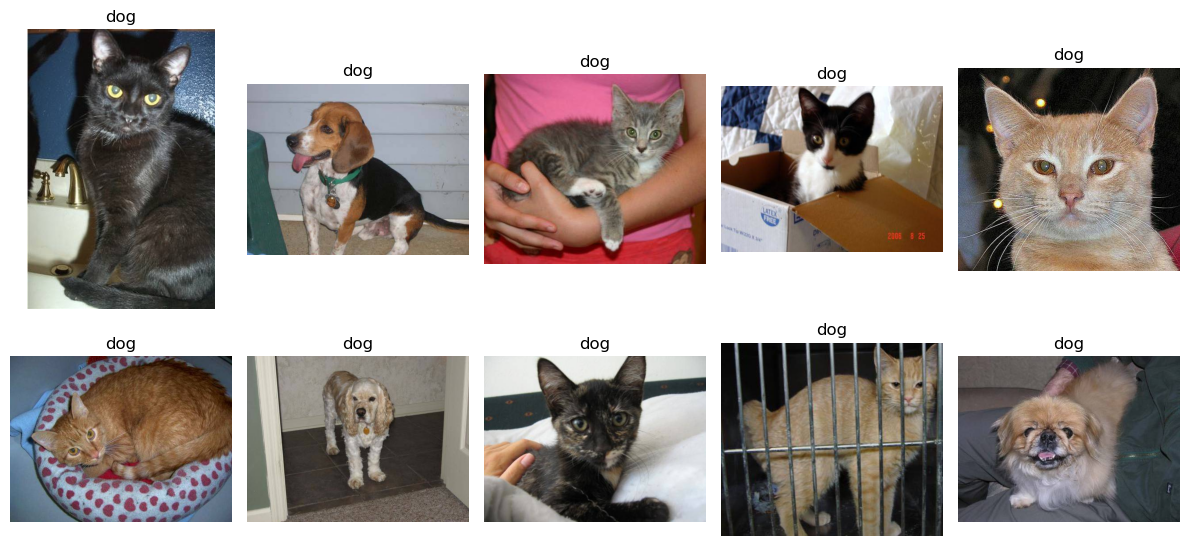

In [97]:
display_image_grid(test_images_filepaths)

## VGGNet (VGG11)

In [99]:
# 필요한 라이브러리 호출
import copy # 객체 복사
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device = torch.device('cpu')

In [137]:
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self.features = features
        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim)
        )  # 완전 연결층과 출력층 정의

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

In [138]:
# 모델 유형 정의
# 숫자 (output channel, 출력 채널): Conv2d 수행
# 출력 채널이 다음 계층의 입력 채널이 됨
# M: 최대 풀링을 수행

# 합성곱층 8 + 풀링층 3 = 전체 계층 11
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# 합성곱층 10 + 풀링층 3 = 전체 계층 13
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# 합성곱층 13 + 풀링층 3 = 전체 계층 16
vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

# 합성곱층 16 + 풀링층 3 = 전체 계층 19
vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']

In [139]:
# VGG 계층 정의
def get_vgg_layers(config, batch_norm):
    layers = []
    in_channels = 3

    for c in config: # vgg11_config의 값들을 가져옴
        assert c == 'M' or isinstance(c, int)
        if c == 'M': # 불러온 값이 M이라면 최대 풀링 적용
            layers += [nn.MaxPool2d(kernel_size=2)]
        else: # 불러온 값이 숫자이면 합성곱 적용 
            conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding = 1)
            if batch_norm: # 배치 정규화를 적용할지에 대한 코드
                # 배치 정규화가 적용될 경우 배치 정규화 + ReLU 사용
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            else:
                # 배치 정규화가 적용되지 않을 경우 ReLU만 적용
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = c
    return nn.Sequential(*layers) # 네트워크의 모든 계층 반환

In [140]:
# 모델 계층 생성 (배치 정규화 계층 추가)
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

In [141]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [142]:
OUTPUT_dim = 2
model = VGG(vgg11_layers, OUTPUT_dim)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

- VGG는 사전 훈련된 모델
- 즉, 이미 누군가가 대용량의 이미지 데이터로 학습 시켰으며, 최상의 상태로 튜닝을 거쳐 모든 사람이 사용할 수 있도록 공유한 사전 훈련된 모델이다

In [143]:
import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained = True)
print(pretrained_model)

/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [144]:
# 이미지 데이터 전처리
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)), # 이미지를 256 * 256 크기로 조정
    transforms.RandomRotation(5), # 5도 이하로 이미지 회전
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)), # 이미지를 256 * 256 크기로 조정
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [145]:
# ImageFolder를 이용해 데이터셋 불러오기
train_path = os.path.join(path, 'chap06/data/catanddog/train/')
test_path = os.path.join(path, 'chap06/data/catanddog/test/')

train_dataset = torchvision.datasets.ImageFolder(
    train_path, 
    transform = train_transforms
)
# ImageFolder는 계층적인 폴더 구조를 가지고 있는 데이터셋을 불러올 때 사용
# train 폴더 하위에 Cat, Dog 폴더가 계층적으로 위치하고 있기 때문에 ImageFolder 사용

test_dataset = torchvision.datasets.ImageFolder(
    test_path, 
    transform = test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [146]:
# 훈련과 검증 데이터 분할
VALID_RATIO = 0.9
# 전체 훈련 데이터 중 90%를 훈련 데이터셋으로 사용
n_train_example = int(len(train_dataset) * VALID_RATIO)
# 전첸 훈련 데이터 중 남은 10%를 검증 데이터셋으로 사용
n_valid_example = int(len(train_dataset) - n_train_example)

train_data, valid_data = data.random_split(train_dataset,
                                           [n_train_example, n_valid_example])

In [147]:
# 검증 데이터 전처리
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [148]:
# 훈련, 검증, 테스트 데이터셋 수 확인
print(f'Number of Training Example: {len(train_data)}')
print(f'Number of Validation Example: {len(valid_data)}')
print(f'Number of Testing Example: {len(test_dataset)}')

Number of Training Example: 476
Number of Validation Example: 53
Number of Testing Example: 12


In [149]:
# 메모리로 데이터 불러오기
BATCH_SIZE = 128
# 훈련 데이터셋은 임의로 섞어서 가져옴
train_iterator = data.DataLoader(train_data, shuffle = True, 
                                 batch_size = BATCH_SIZE)
valid_iterator = data.DataLoader(valid_data, 
                                 batch_size = BATCH_SIZE)
test_iterator = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [150]:
# 모델 학습에서 사용할 옵티마이저와 손실 함수 정의
optimizer = optim.Adam(model.parameters(), lr = 1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [151]:
# 모델 정확도 측정 함수
def calcualte_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim = True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [152]:
# 모델 학습 함수 정의 

def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x,y) in iterator: # epoch를 10으로 설정했으므로 10회 반복
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calcualte_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)
    

In [153]:
# 모델 성능 측정 함수
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calcualte_accuracy(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [154]:
# 학습 시간 측정 함수
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
# 모델 학습
EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):
    start_time = time.monotonic()
    # 훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    # 검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    # valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-model.pt로 저장
    if valid_loss < best_valid_loss: 
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'chap06/data/VGG-model.pt')
    
    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time) # 모델 훈련 시작, 종료 시간 저장

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc * 100:.2f}%')
    print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc * 100:.2f}%')

Epoch: 01 | Epoch Time: 3m 34s
	Train Loss: 0.694 | Train Acc: 50.93%
	Valid Loss: 0.693 | Valid Acc: 52.83%
Epoch: 02 | Epoch Time: 2m 54s
	Train Loss: 0.695 | Train Acc: 51.59%
	Valid Loss: 0.693 | Valid Acc: 52.83%
Epoch: 03 | Epoch Time: 2m 59s
	Train Loss: 0.691 | Train Acc: 52.51%
	Valid Loss: 0.692 | Valid Acc: 54.72%
Epoch: 04 | Epoch Time: 3m 29s
	Train Loss: 0.688 | Train Acc: 50.66%
	Valid Loss: 0.691 | Valid Acc: 64.15%
Epoch: 05 | Epoch Time: 3m 26s
	Train Loss: 0.702 | Train Acc: 50.35%
	Valid Loss: 0.691 | Valid Acc: 73.58%


In [159]:
# 테스트 데이터셋을 이용한 모델 성능 측정
model.load_state_dict(torch.load('chap06/data/VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc * 100:.2f}%')

/var/folders/39/w11v66x90d9bmgkv6q0r4cc80000gn/T/ipykernel_9210/1071260321.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('chap06/data/

Test Loss: 0.695 | Test Acc: 41.67%


In [161]:
# 테스트 데이터셋을 이용한 모델의 예측 확인 함수
def get_predictions(model, iterator):
    model.eval()
    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred, _ = model(x)
            y_prob = F.softmax(y_pred, dim = 1)
            top_pred = y_prob.argmax(1, keepdim = True)
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())
    
    # 앞에서 정의한 get_predictions() 함수의 반환값을 각각 images, labels, probs에 저장
    images = torch.cat(images, dim = 0)
    labels = torch.cat(labels, dim = 0)
    probs = torch.cat(probs, dim = 0)
    return images, labels, probs

In [183]:
# 예측 중에서 정확하게 예측한 것 추출
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels) # 예측과 정답이 같은지 비교
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key = lambda x: torch.max(x[2], dim =0).values)

In [184]:
# 이미지 출력을 위한 전처리
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

In [185]:
# 모델이 정확하게 예측한 이미지 출력 함수 
def plot_most_correct(correct, classes, n_images, normalize = True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize = (25, 20))
    for i in range(rows * cols):
        ax = fig.add_subplot(rows, cols, i + 1) # 출력하려는 그래프 개수만큼 subplot을 만듦
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0)

        true_prob = probs[true_label]
        correct_prob, correct_label = torch.max(probs, dim = 0)
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize:
            image = normalize_image(image)
            
        ax.imshow(image.cpu().numpy())
        ax.set_title(f'True label: {true_class} ({true_prob:.3f})\n' \
                     f'Pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')
    fig.subplots_adjust(hspace = 0.4)

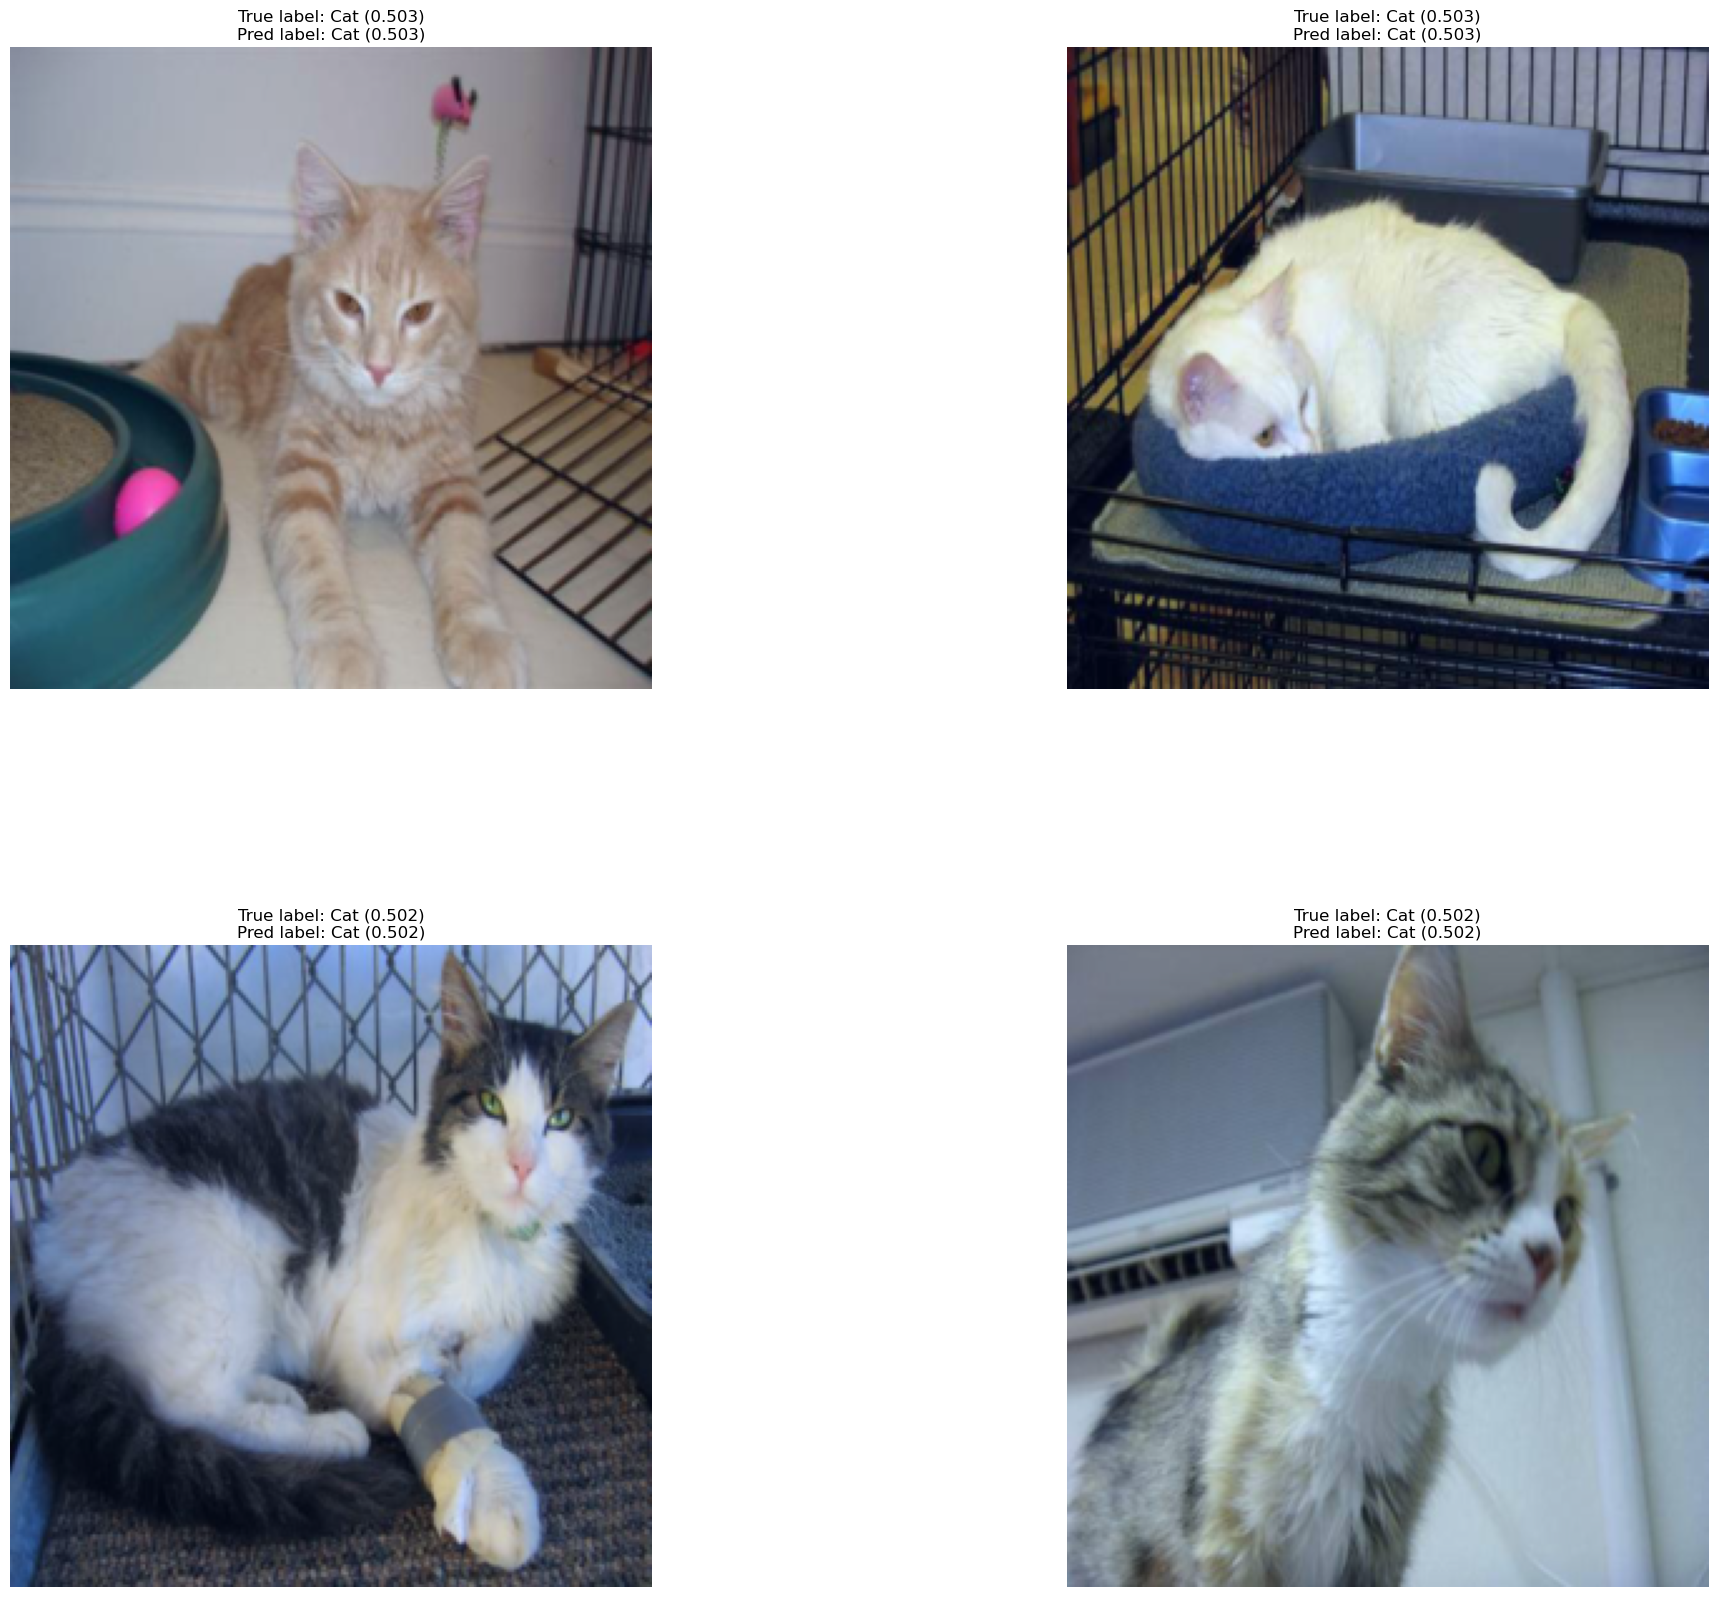

In [186]:
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)